In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, classification_report, accuracy_score

import time
import psutil
import warnings
warnings.filterwarnings("ignore")

In [10]:
normal_df = pd.read_csv("./Processed_Datasets/Dataset_Benign.csv")
dos_df = pd.read_csv("./Processed_Datasets/Dataset_BruteForce.csv")

df = pd.concat([normal_df, dos_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,-0.130506,0.456772,-0.220458,-0.279816,-0.220760,-0.363309,-0.200337,0.313033,-0.095920,-0.043581,...,-0.561417,-0.288389,-0.343212,-0.476188,-0.323661,-0.476188,-0.002732,-0.773916,-0.205316,1
1,-0.205664,-0.493369,-0.137961,-0.271325,0.560642,0.040249,-0.200337,-0.179411,0.148339,-0.043581,...,-0.567852,-0.288389,-0.450707,-0.501906,-0.400908,-0.501906,-0.004301,-0.773916,-0.209700,0
2,1.109605,-0.493369,-0.506622,-0.272614,1.342044,-0.363309,-0.200337,0.805476,1.369632,-0.043581,...,-0.587211,-0.265477,-0.504455,-0.579277,-0.458879,-0.579277,-0.004240,-0.773916,-0.211693,1
3,1.034446,-0.493369,0.398273,-0.280158,1.342044,0.443808,-0.200337,0.313033,0.881115,-0.043581,...,-0.545573,-0.265477,0.033022,-0.412865,0.026743,-0.412865,-0.002429,-0.773916,-0.160631,1
4,1.222342,-0.493369,0.021878,-0.202551,-0.220760,-0.363309,-0.200337,-0.671854,1.369632,-0.043581,...,0.460192,-0.265477,4.114488,3.606747,4.925776,3.606747,-0.004595,-0.773916,4.719618,0


In [11]:
df["Label"].value_counts()

Label
1    500000
0    500000
Name: count, dtype: int64

In [12]:
X = df.drop("Label", axis=1)
y = df["Label"]

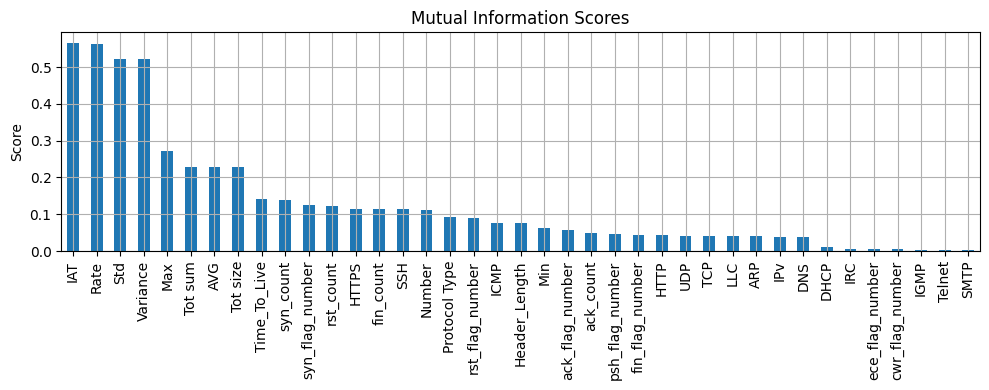

Selected Features (20): ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'syn_flag_number', 'rst_flag_number', 'syn_count', 'fin_count', 'rst_count', 'HTTPS', 'SSH', 'ICMP', 'Tot sum', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']


In [13]:
# Feature selection

mi = mutual_info_classif(X, y)
features = X.columns
mi_series = pd.Series(mi, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
mi_series.plot(kind='bar')
plt.title("Mutual Information Scores")
plt.ylabel("Score")
plt.tight_layout()
plt.grid()
plt.show()

k = 20
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_selected = selector.fit_transform(X, y)
selected_features = features[selector.get_support()]
print(f"Selected Features ({k}):", list(selected_features))

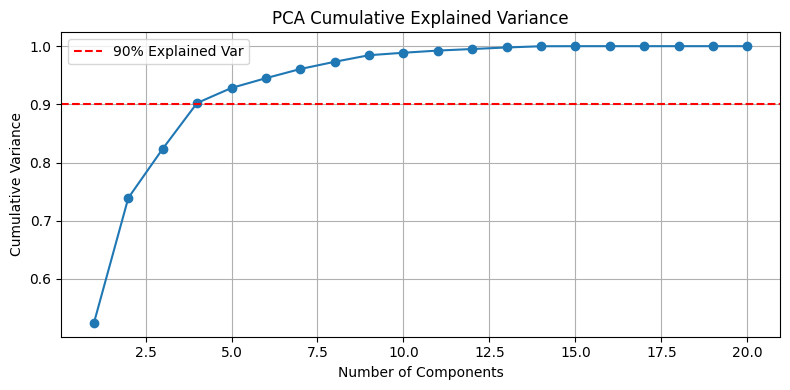

PCA selected components: 4


In [14]:
# Dimension reduction

pca = PCA()
X_pca_all = pca.fit_transform(X_selected)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Explained Var')
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

n_components = np.argmax(explained >= 0.90) + 1
print(f"PCA selected components: {n_components}")
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X_selected)

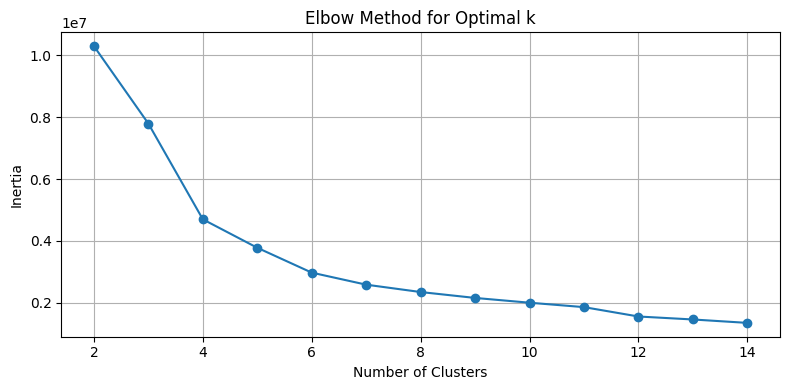

Silhouette Score: 0.3598
Calinski-Harabasz Index: 768299.32


In [15]:
# Clustering

inertia_list = []
K = range(2, 15)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_reduced)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia_list, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid()
plt.tight_layout()
plt.show()

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

sil = silhouette_score(X_reduced, clusters)
ch = calinski_harabasz_score(X_reduced, clusters)
print(f"Silhouette Score: {sil:.4f}")
print(f"Calinski-Harabasz Index: {ch:.2f}")

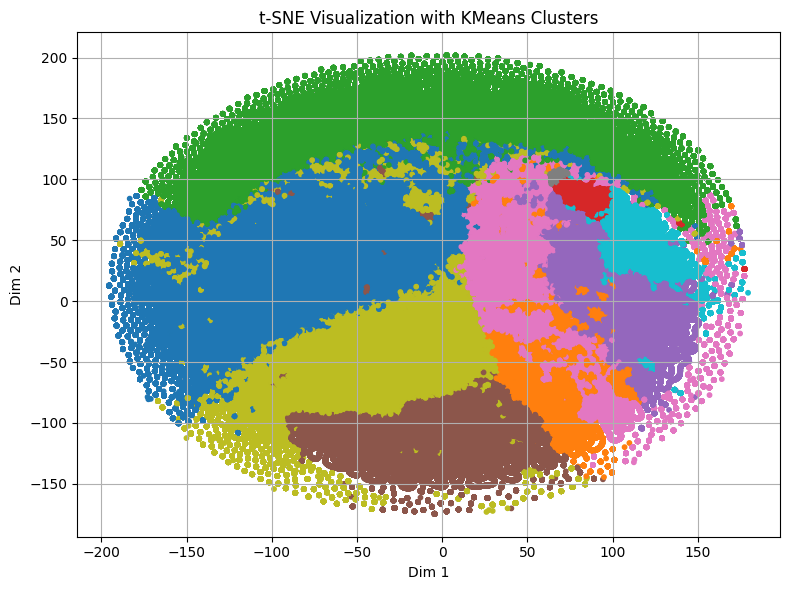

In [16]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10', s=10)
plt.title("t-SNE Visualization with KMeans Clusters")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid()
plt.tight_layout()
plt.show()

In [17]:
distances = kmeans.transform(X_reduced)
min_dist = np.min(distances, axis=1)
threshold = np.percentile(min_dist, 80)
selected_indices = np.where(min_dist <= threshold)[0]

X_final = X_reduced[selected_indices]
y_final = y.iloc[selected_indices].values

print(f"Selected {len(X_final)} samples out of {len(X_reduced)} (Top 80%)")

Selected 800000 samples out of 1000000 (Top 80%)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

start_time = time.time()
cpu_usage_start = psutil.cpu_percent(interval=1)
memory_usage_start = psutil.virtual_memory().percent

model = LGBMClassifier(n_estimators=430, learning_rate=0.3, num_leaves=180, max_depth=60, subsample=0.3, colsample_bytree=0.5, reg_alpha=0.5, reg_lambda=0.5, random_state=42)
model.fit(X_train, y_train)

end_time = time.time()
cpu_usage_end = psutil.cpu_percent(interval=1)
memory_usage_end = psutil.virtual_memory().percent

training_time = end_time - start_time
cpu_usage_diff = cpu_usage_end - cpu_usage_start
memory_usage_diff = memory_usage_end - memory_usage_start

print(f"Model training took {training_time:.2f} seconds")
print(f"CPU Usage during training: {cpu_usage_start}% -> {cpu_usage_end}% (Change: +{cpu_usage_diff}%)")
print(f"Memory Usage during training: {memory_usage_start}% -> {memory_usage_end}% (Change: +{memory_usage_diff}%)")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.8f}')

[LightGBM] [Info] Number of positive: 309822, number of negative: 330178
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 640000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.484097 -> initscore=-0.063634
[LightGBM] [Info] Start training from score -0.063634
Model training took 3.77 seconds
CPU Usage during training: 2.2% -> 11.4% (Change: +9.2%)
Memory Usage during training: 42.9% -> 42.9% (Change: +0.0%)
Test Accuracy: 0.97073750


In [19]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     82610
           1       0.95      1.00      0.97     77390

    accuracy                           0.97    160000
   macro avg       0.97      0.97      0.97    160000
weighted avg       0.97      0.97      0.97    160000

